In [1]:
# ===============================
# DATA MANIPULATION
# ===============================

import pandas as pd
import numpy as np

# ===============================
# DATA VISUALIZATION
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
plt.style.use("ggplot")

# Display plots inside Colab
%matplotlib inline

# ===============================
# IGNORE WARNINGS
# ===============================

import warnings
warnings.filterwarnings("ignore")

# ===============================
# MACHINE LEARNING
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# ===============================
# SAVE MODEL
# ===============================

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.shape


(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe ()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


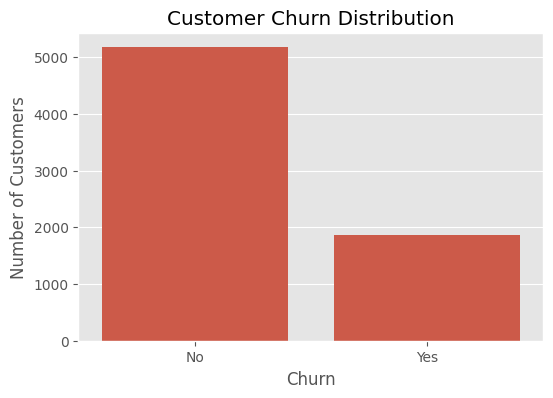

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


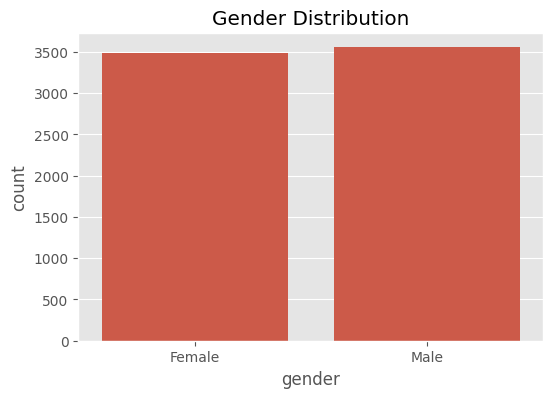

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")

plt.show()

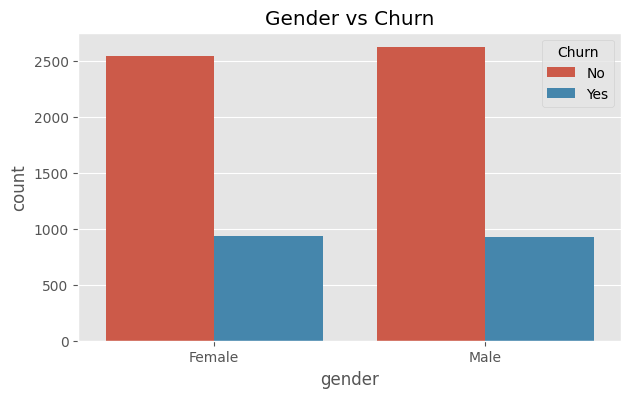

In [19]:
plt.figure(figsize=(7,4))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

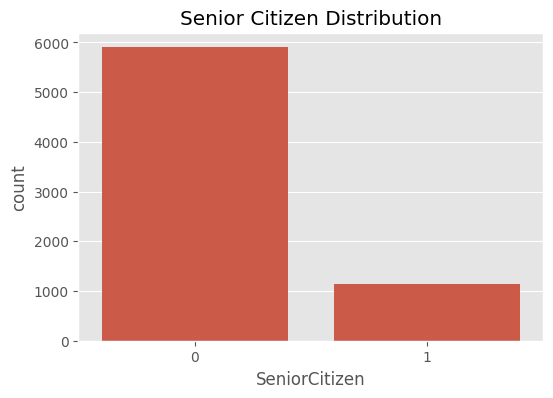

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", data=df)

plt.title("Senior Citizen Distribution")

plt.show()

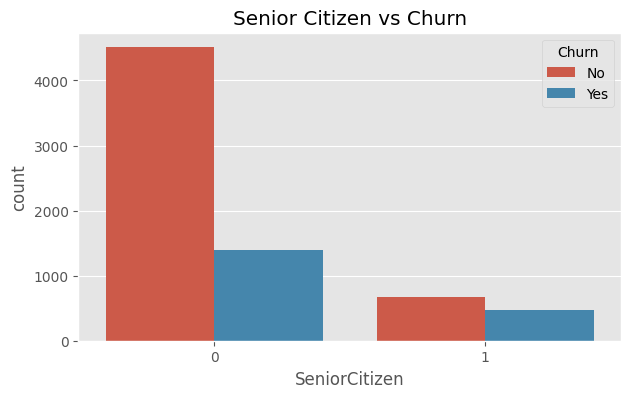

In [21]:
plt.figure(figsize=(7,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.show()

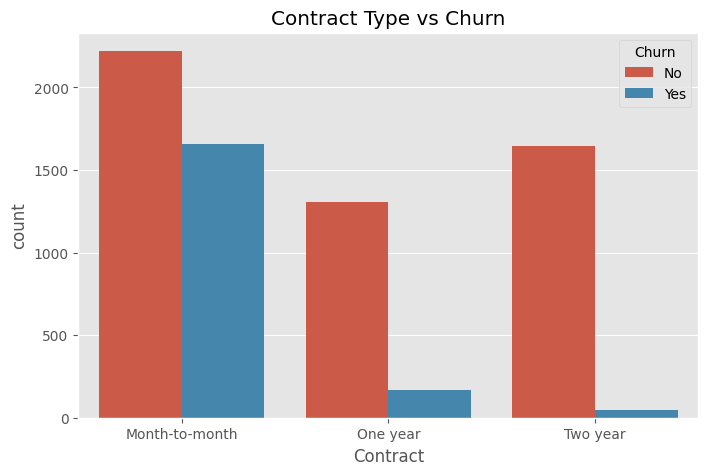

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

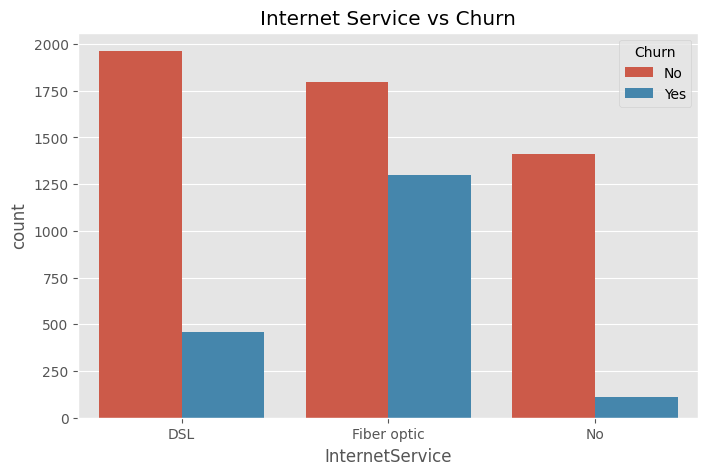

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

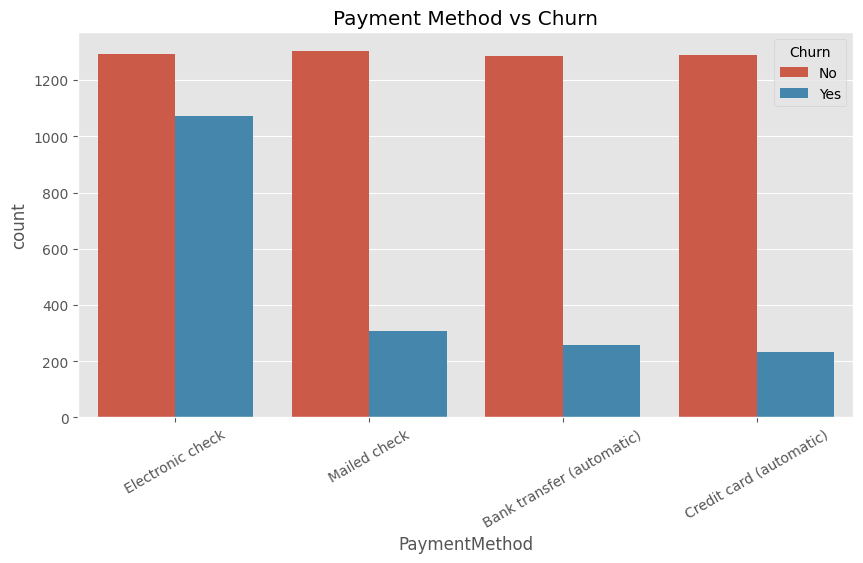

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=30)

plt.title("Payment Method vs Churn")

plt.show()

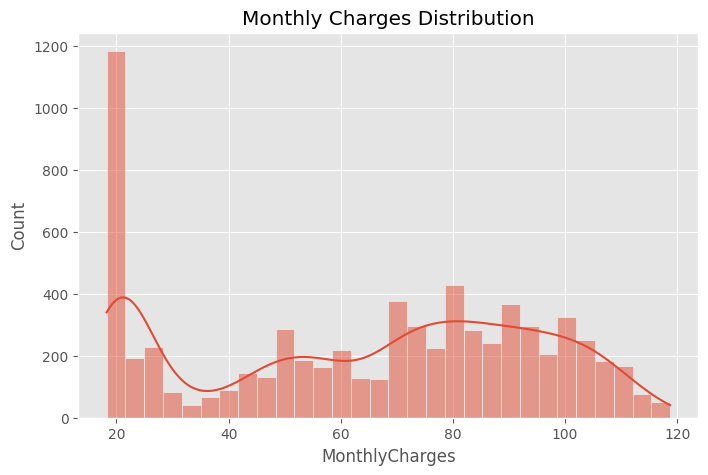

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

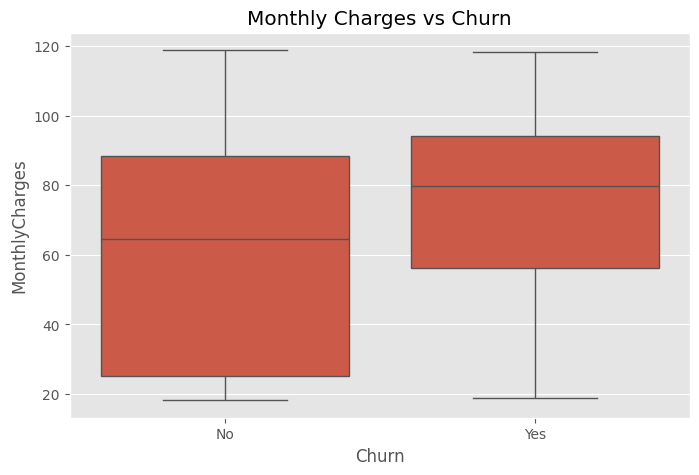

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

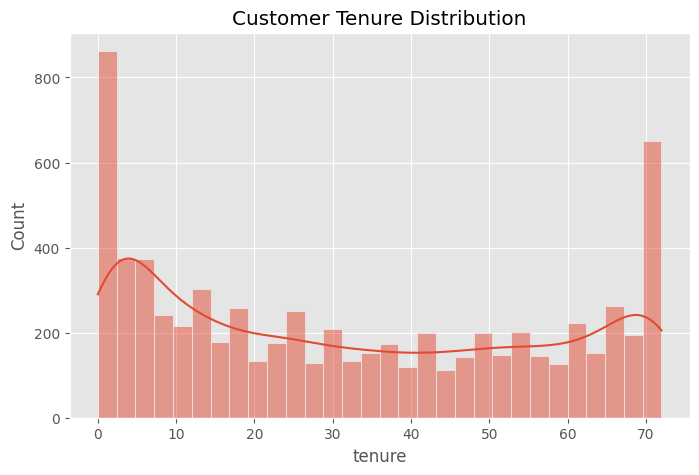

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

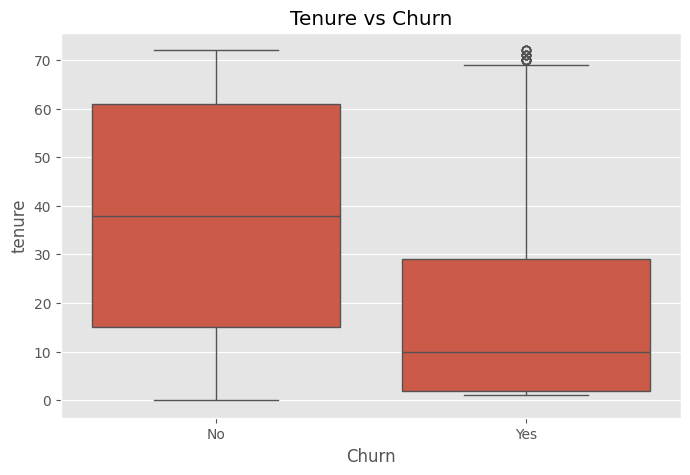

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

In [29]:
eda_df = df.copy()

for col in eda_df.select_dtypes(include="object").columns:
    eda_df[col] = eda_df[col].astype("category").cat.codes

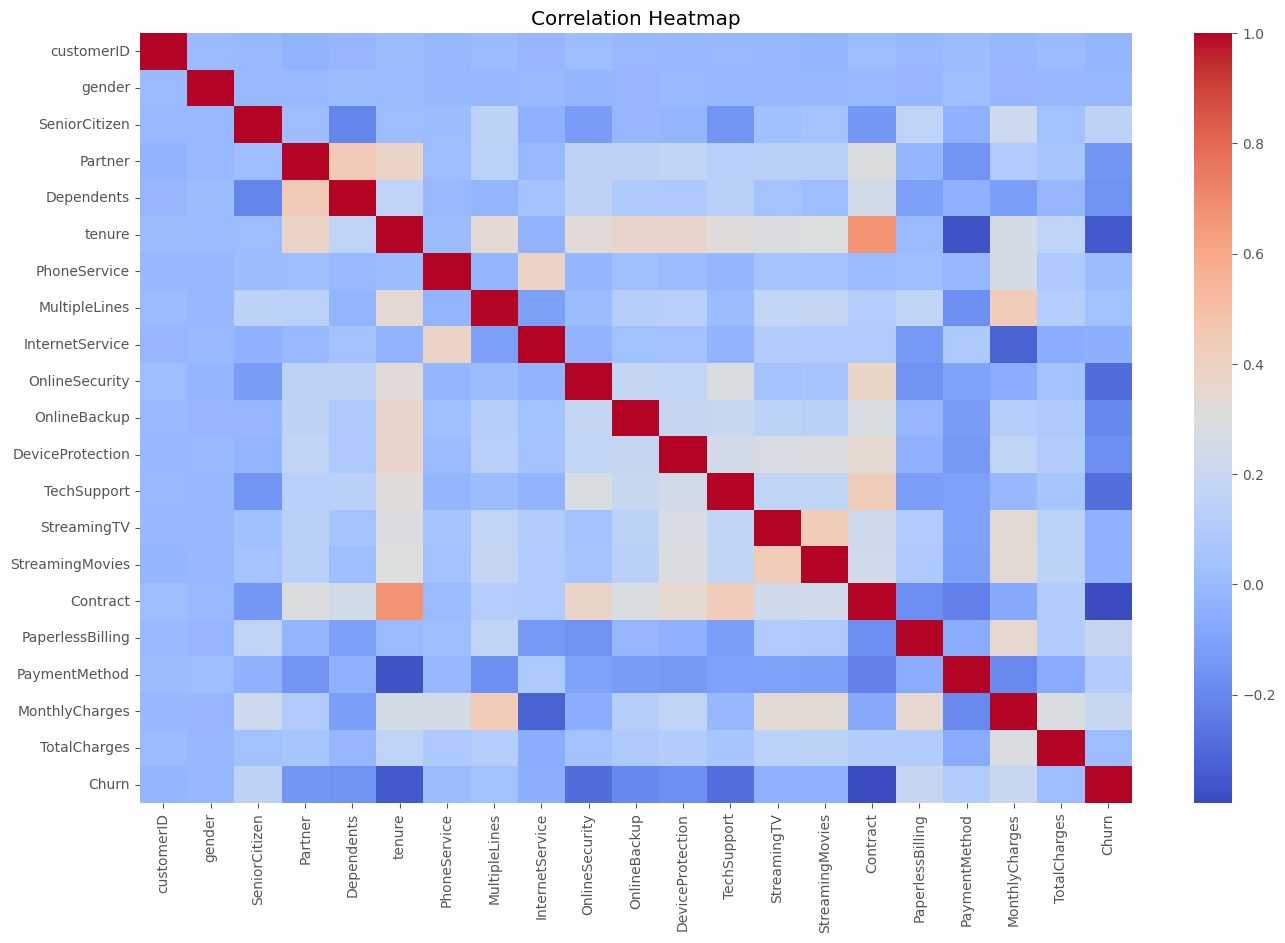

In [30]:
plt.figure(figsize=(16,10))

sns.heatmap(
    eda_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()


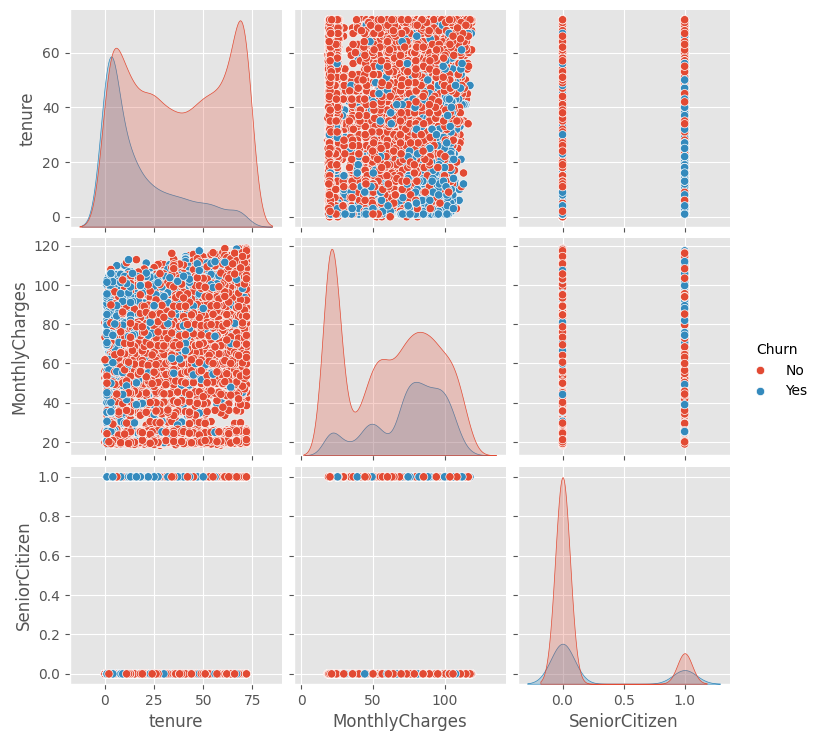

In [31]:
sns.pairplot(
    df[
        [
            "tenure",
            "MonthlyCharges",
            "SeniorCitizen",
            "Churn"
        ]
    ],
    hue="Churn"
)

plt.show()

In [32]:
data = df.copy()


In [33]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [34]:
data["TotalCharges"] .head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [35]:
(data["TotalCharges"] == " ").sum()

np.int64(11)

In [37]:
data["TotalCharges"] = data["TotalCharges"].replace(" ",np.nan)

In [38]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [39]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"])

In [40]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [41]:
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

In [42]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [43]:
data.drop("customerID", axis=1, inplace=True)

In [44]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
data["Churn"] = data["Churn"].map({
    "No":0,
    "Yes":1
})

In [46]:
data["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [47]:
categorical_columns = data.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [48]:
data = pd.get_dummies(
    data,
    drop_first=True
)

In [49]:
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [50]:
X = data.drop("Churn", axis=1)

In [51]:
y = data["Churn"]

In [105]:
import joblib

# Save feature column names
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("feature_columns.pkl saved successfully!")


feature_columns.pkl saved successfully!


In [106]:
from google.colab import files

files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 30)
Testing Features  : (1409, 30)
Training Labels   : (5634,)
Testing Labels    : (1409,)


In [55]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [56]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [57]:
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nData Cleaning Completed Successfully!")

Training Shape : (5634, 30)
Testing Shape : (1409, 30)

Data Cleaning Completed Successfully!


In [59]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(random_state=42)

# Train model
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [60]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Prediction probabilities
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [61]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision :", precision_score(y_test, y_pred_lr))

print("Recall :", recall_score(y_test, y_pred_lr))

print("F1 Score :", f1_score(y_test, y_pred_lr))

print("ROC AUC :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8069552874378992
Precision : 0.6583850931677019
Recall : 0.5668449197860963
F1 Score : 0.6091954022988506
ROC AUC : 0.8415846443979436


In [62]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [63]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

cm

array([[925, 110],
       [162, 212]])

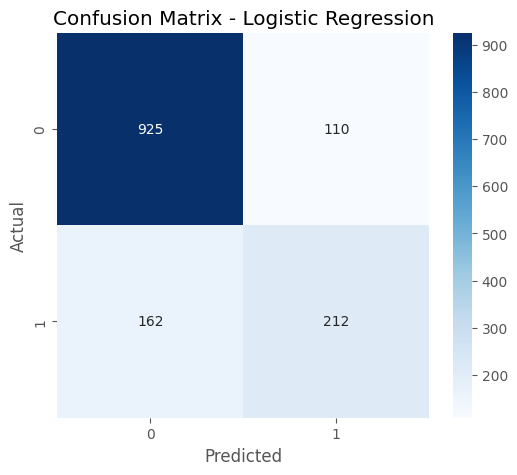

In [64]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

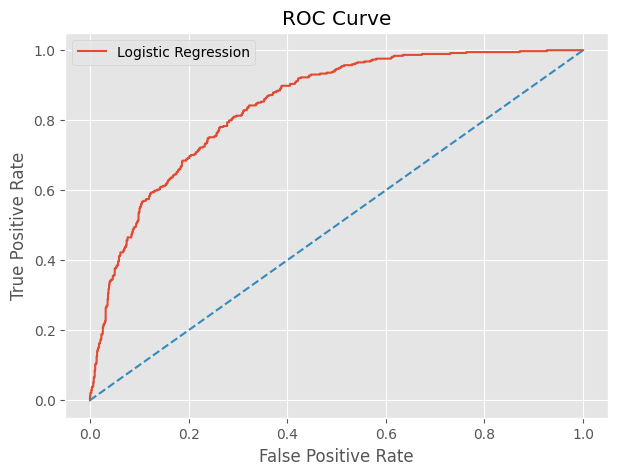

In [65]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [66]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [67]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Decision Tree ROC AUC:",
      roc_auc_score(y_test, y_prob_dt))

Decision Tree Accuracy: 0.7409510290986515
Decision Tree ROC AUC: 0.6609574000878348


In [68]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [69]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Random Forest ROC AUC:",
      roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.7856635911994322
Random Forest ROC AUC: 0.8246454312950475


In [70]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [71]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("Gradient Boosting ROC AUC:",
      roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Accuracy: 0.7984386089425124
Gradient Boosting ROC AUC: 0.8420935699708079


In [72]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_gb)
    ],

    "ROC_AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_dt),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_gb)
    ]

})

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,ROC_AUC
3,Gradient Boosting,0.798439,0.842094
0,Logistic Regression,0.806955,0.841585
2,Random Forest,0.785664,0.824645
1,Decision Tree,0.740951,0.660957


In [73]:
joblib.dump(
    rf_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [75]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5
)

RandomForestClassifier(max_depth=10, min_samples_split=5)

In [76]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"]

}


In [77]:
100
200
300

300

In [78]:
grid_search = GridSearchCV(

    estimator=rf_model,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [79]:
estimator=rf_model

In [81]:
cv=5

In [83]:
grid_search.fit(
    X_train,
    y_train
)




Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=2)

In [84]:
print(grid_search.best_params_)




{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [85]:
print(grid_search.best_score_)

0.8454109674708532


In [86]:
best_rf = grid_search.best_estimator_

In [87]:
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:,1]

In [88]:
print("Accuracy")

print(accuracy_score(
    y_test,
    y_pred_best
))

print()

print("Precision")

print(precision_score(
    y_test,
    y_pred_best
))

print()

print("Recall")

print(recall_score(
    y_test,
    y_pred_best
))

print()

print("F1")

print(f1_score(
    y_test,
    y_pred_best
))

print()

print("ROC AUC")

print(roc_auc_score(
    y_test,
    y_prob_best
))

Accuracy
0.8034066713981547

Precision
0.6713780918727915

Recall
0.5080213903743316

F1
0.578386605783866

ROC AUC
0.8445309876256167


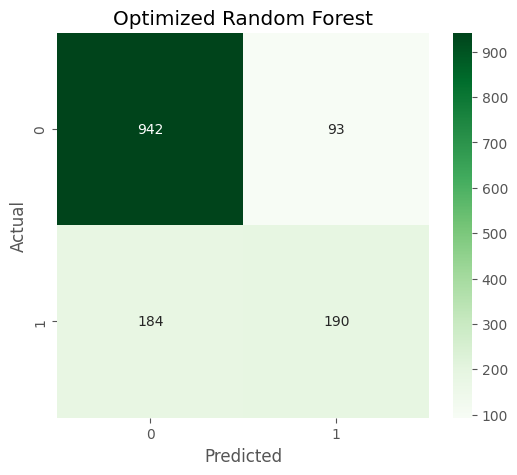

In [89]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Optimized Random Forest")

plt.show()

In [90]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest (Default)",
        "Random Forest (Tuned)"
    ],

    "ROC_AUC":[

        roc_auc_score(
            y_test,
            y_prob_rf
        ),

        roc_auc_score(
            y_test,
            y_prob_best
        )

    ]

})

comparison

,Model,ROC_AUC
0,Random Forest (Default),0.824645
1,Random Forest (Tuned),0.844531


In [91]:
joblib.dump(
    best_rf,
    "customer_churn_model.pkl"
)

print("Optimized model saved successfully!")

Optimized model saved successfully!


In [92]:
!pip install shap -q

In [93]:
import shap

In [94]:
explainer = shap.TreeExplainer(best_rf)

In [95]:
shap_values = explainer.shap_values(X_test)

In [97]:
import numpy as np

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]   # Positive class
else:
    shap_values_plot = shap_values

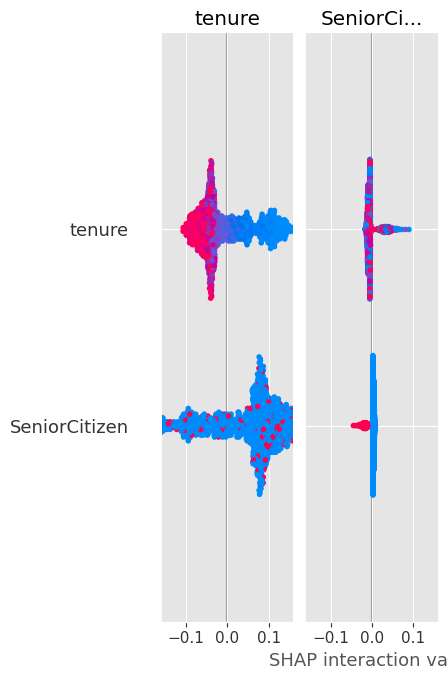

In [98]:
shap.summary_plot(
    shap_values_plot,
    X_test,
    feature_names=X.columns
)

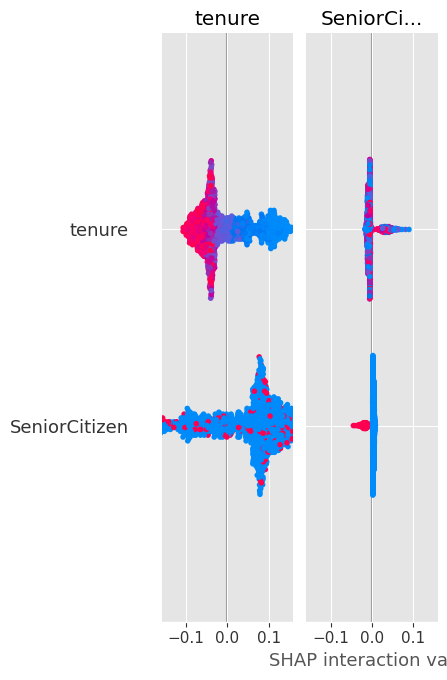

In [99]:
shap.summary_plot(
    shap_values_plot,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

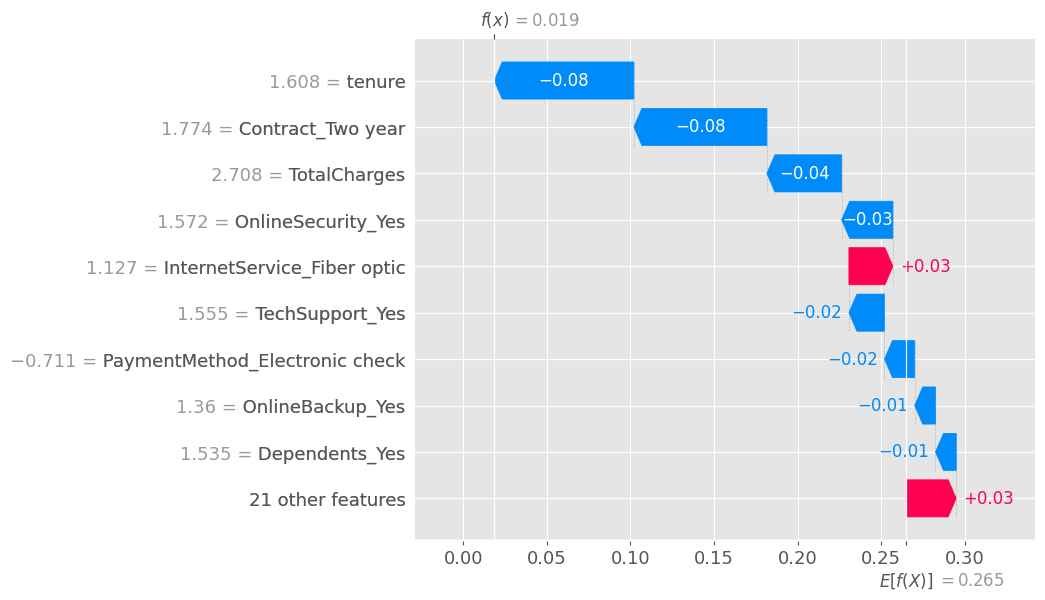

In [102]:
sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_plot[sample_index, :, 1], # Select SHAP values for the positive class
        base_values=explainer.expected_value[1], # Select expected value for the positive class
        data=X_test[sample_index],
        feature_names=X.columns
    )
)

In [103]:
prediction = best_rf.predict(X_test[0].reshape(1,-1))

probability = best_rf.predict_proba(X_test[0].reshape(1,-1))

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [0]
Probability: [[0.98142239 0.01857761]]


In [104]:
plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>